In [17]:
import json
import pandas as pd

from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
vader = SentimentIntensityAnalyzer()
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import PercentFormatter
from matplotlib import patches as mpatches
from elasticsearch import Elasticsearch
import importlib
import analysis_utils
import requests
from requests.packages.urllib3.exceptions import InsecureRequestWarning
requests.packages.urllib3.disable_warnings(InsecureRequestWarning)


In [18]:
importlib.reload(analysis_utils)

<module 'analysis_utils' from '/home/jovyan/analysis_utils.py'>

In [33]:
records = analysis_utils.fetch_data_from_index("social-media-harvest", size=10000)

data = analysis_utils.preprocess_data(records)

df = pd.DataFrame(data)
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

df.head()


Processing record 0
Processing record 1000
Processing record 2000
Processing record 3000
Processing record 4000
Processing record 5000
Processing record 6000
Processing record 7000
Processing record 8000
Processing record 9000


,platform,id,type,source,text,datetime,author,parent_id,textblob_sentiment,vader_sentiment,total_sentiment,subjectivity,sentiment
0,reddit,jlrawk2,comment,australia,1. Get cheap lollies from wholesaler - check 2...,2023-05-26 23:01:26+00:00,dosfivepointone,13sr2s2,0.200000,0.0000,0.100000,0.350000,positive
1,reddit,jlrec6a,comment,australia,Are you in an airport or something?,2023-05-26 23:28:22+00:00,KittikatB,13sr2s2,0.000000,0.0000,0.000000,0.000000,neutral
2,reddit,jlreo2w,comment,australia,How are you supposed to parse T LUX AU anyway?...,2023-05-26 23:31:00+00:00,Ok-Push9899,13sr2s2,0.000000,-0.4588,-0.229400,0.000000,negative
3,reddit,jlrrpur,comment,australia,You used to get red and green frogs for 2c eac...,2023-05-27 01:17:25+00:00,Articulated_Lorry,13sr2s2,0.035417,0.0000,0.017708,0.291667,positive
4,reddit,jlrcf9x,comment,australia,That bag doesn’t look big enough for 400g of l...,2023-05-26 23:13:25+00:00,123chuckaway,13sr2s2,0.000000,0.0000,0.000000,0.300000,neutral


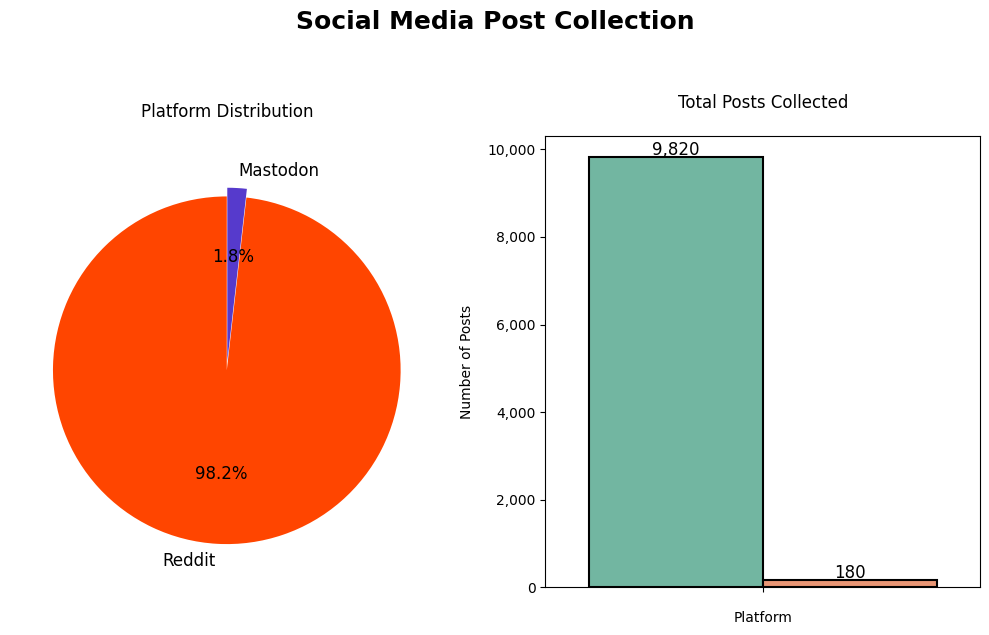

In [34]:
platform_counts = {
    'Reddit': len(df[df['platform'] == 'reddit']),
    'Mastodon': len(df[df['platform'] == 'mastodon'])
}

plt.figure(figsize=(10, 6))
plt.suptitle('Social Media Post Collection', fontsize=18, fontweight='bold', y=1.05)

plt.subplot(1, 2, 1)
colors = ['#FF4500', '#563ACC']  
explode = (0.05, 0) 
plt.pie(
    platform_counts.values(),
    labels=platform_counts.keys(),
    colors=colors,
    explode=explode,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12}
)
plt.title('Platform Distribution', pad=20)

plt.subplot(1, 2, 2)
ax = sns.barplot(
    hue =list(platform_counts.keys()),
    y =list(platform_counts.values()),
    palette='Set2',
    edgecolor='black',
    linewidth=1.5,
    legend= False
)

plt.title('Total Posts Collected', pad=20)
plt.xlabel('Platform', labelpad=10)
plt.ylabel('Number of Posts', labelpad=10)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}')) 

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}', 
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center', 
        xytext=(0, 5), 
        textcoords='offset points',
        fontsize=12
    )

plt.tight_layout()

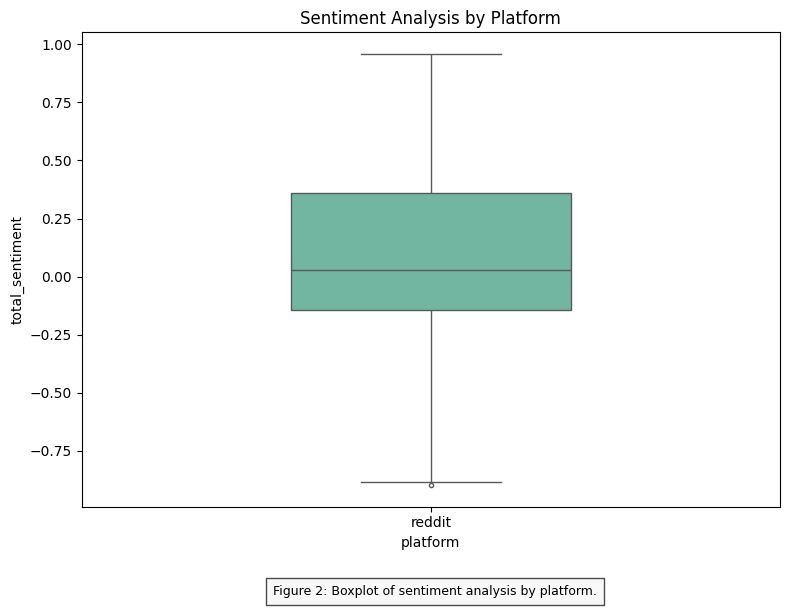

In [37]:
mastodon_count = df['platform'].value_counts().get('mastodon', 0)


# create visualisation of sentiment analysis by platform
plt.figure(figsize=(8, 6))
sns.boxplot(x='platform', hue='platform', y='total_sentiment', data=df, palette='Set2', width = 0.4, fliersize=3, legend=False)
plt.title('Sentiment Analysis by Platform')
plt.figtext(0.55, 0,
           "Figure 2: Boxplot of sentiment analysis by platform.",
           ha="center", 
           fontsize=9,
           multialignment="left",
           bbox={"facecolor":"#f7f7f7", "alpha":0.7, "pad":5})
plt.subplots_adjust(bottom=0.3)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


Mastodon vs Reddit
Chronological feed  Algorithmic (hot/top/controversial)
Decentralized microblogging (like Twitter)  Centralized forum-based platform
More positive/neutral tone (no downvotes)   Polarized (via upvotes/downvotes)


sentiment
positive    5073
negative    3406
neutral     1521
Name: count, dtype: int64
sentiment  negative  neutral  positive
platform                              
mastodon         71       34        75
reddit         3335     1487      4998


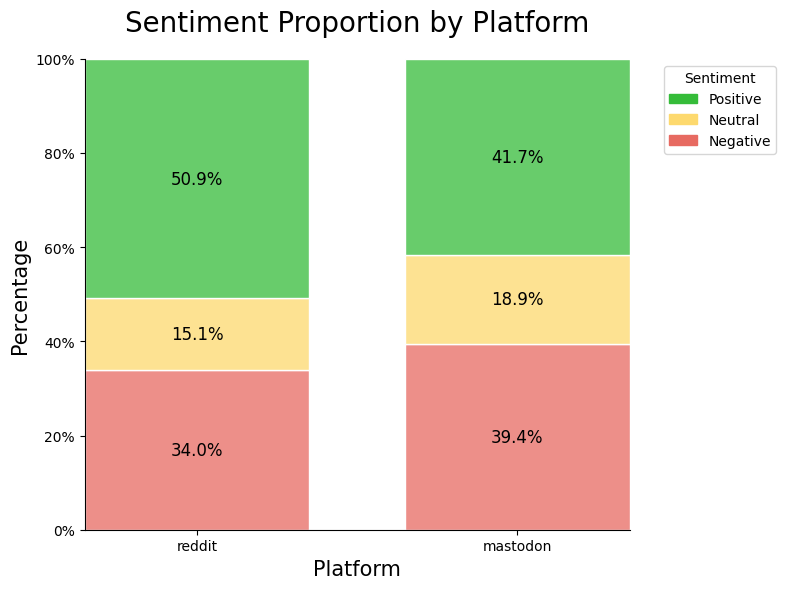

In [21]:
print(df['sentiment'].value_counts())
print(pd.crosstab(df['platform'], df['sentiment']))
sentiment_order = ['positive', 'neutral', 'negative']
palette = ["#35BC39","#FDD96E", "#E76A61"]
plt.figure(figsize=(8, 6))
ax = sns.histplot(
    data=df,
    x='platform',
    hue='sentiment',
    hue_order=sentiment_order,
    stat='percent',
    multiple='fill',
    palette = palette,
    edgecolor='white',
    shrink=0.7,
)
plt.title('Sentiment Proportion by Platform', pad=20, fontsize=20)
plt.xlabel('Platform', fontsize=15)
plt.ylabel('Percentage', fontsize=15)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    x = bar.get_x() + bar.get_width()/2
    y = bar.get_y() + height/2
    
    ax.text(
        x, y,
        f'{height*100:.1f}%',
        ha='center',
        va='center',
        color='black',
        fontsize=12,
    )

handles = [
    mpatches.Patch(color="#35BC39", label='Positive'),
    mpatches.Patch(color="#FDD96E", label='Neutral'),
    mpatches.Patch(color="#E76A61", label='Negative')
]
plt.legend(
    handles=handles,
    title='Sentiment',
    bbox_to_anchor=(1.05, 1),
    frameon=True
)

sns.despine()
plt.tight_layout()
plt.show()

In [24]:
# check out how many posts from each year  and platform
#df['datetime'] = pd.to_datetime(df['timestamp'], format='ISO8601')
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
time = {
    'earlist': df['datetime'].min(),
    'latest': df['datetime'].max(),
}
print(time)
print(pd.crosstab(
    df['datetime'].dt.year,
    df['platform'],
    colnames=['Platform']
))

{'earlist': Timestamp('2012-05-11 09:55:43+0000', tz='UTC'), 'latest': Timestamp('2025-05-20 17:00:32+0000', tz='UTC')}
Platform  mastodon  reddit
datetime                  
2012.0           0      12
2013.0           0      43
2014.0           0      20
2015.0           0      97
2016.0           0     147
2017.0           0     210
2018.0           0     328
2019.0           0     309
2020.0           0     546
2021.0           0     623
2022.0           0    1075
2023.0           0    1406
2024.0           0    2713
2025.0         179    2291


In [26]:
# calculate average sentiment by month from 2024-01 to 2025-06
df['month'] = df['datetime'].dt.to_period('M')

start = '2024-05'
end = '2025-06'
mask = (df['month'] >= start) & (df['month'] <= end)
df_filtered = df.loc[mask]

monthly_avg = (
    df_filtered.groupby(['month'])
    ['total_sentiment'].mean()
    .round(2)
)
polarity_avg = (
    df_filtered.groupby(['month'])
    ['subjectivity'].mean()
    .round(2)
)

print("Monthly Average Sentiment:")
print(monthly_avg)

print("Monthly Average Polarity:")
print(polarity_avg)

Monthly Average Sentiment:
month
2024-05    0.02
2024-06   -0.00
2024-07    0.05
2024-08    0.05
2024-09    0.06
2024-10    0.09
2024-11    0.10
2024-12    0.04
2025-01    0.10
2025-02    0.06
2025-03    0.11
2025-04    0.10
2025-05    0.05
Freq: M, Name: total_sentiment, dtype: float64
Monthly Average Polarity:
month
2024-05    0.38
2024-06    0.39
2024-07    0.39
2024-08    0.39
2024-09    0.39
2024-10    0.39
2024-11    0.42
2024-12    0.36
2025-01    0.39
2025-02    0.39
2025-03    0.40
2025-04    0.39
2025-05    0.30
Freq: M, Name: subjectivity, dtype: float64


/tmp/ipykernel_89/768661807.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['datetime'].dt.to_period('M')


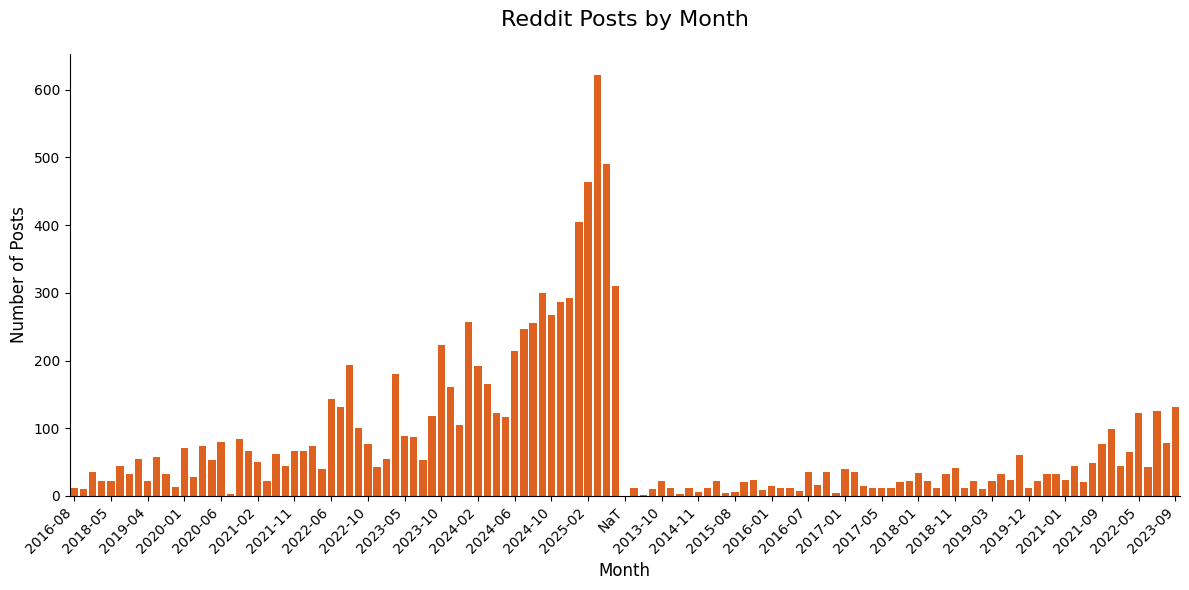

In [27]:
reddit_df = df[df['platform'] == 'reddit'].copy()
monthly_counts = reddit_df['month'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
ax = sns.countplot(
    data=reddit_df,
    x='month',
    color='#FF5700',
    order=sorted(df['month'].unique())
)

tick_labels = [label.get_text() for label in ax.get_xticklabels()]
ax.set_xticks(range(0, len(tick_labels), 4))
ax.set_xticklabels(tick_labels[::4], rotation=45, ha='right', fontsize=10)

plt.title('Reddit Posts by Month', fontsize=16, pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.xticks(rotation=45)


sns.despine()
plt.tight_layout()
plt.show()

**Find most negative post**

In [28]:
#create new df for reddit comments and find the post with most negative comments

comments_df = df[(df['type'] == 'comment') & (df['platform'] == 'reddit')].copy()

post_sentiments = comments_df.groupby('parent_id')['total_sentiment'].agg(['mean', 'count']).rename(columns={'mean': 'avg_sentiment', 'count': 'comment_count'})

significant_posts = post_sentiments[post_sentiments['comment_count'] >= 5]
most_negative_post_id = significant_posts['avg_sentiment'].idxmin()
most_negative_post = df[df['id'] == most_negative_post_id].iloc[0]
negative_comments = df[df['parent_id'] == most_negative_post_id]

print(f"Most Negative Post ID: {most_negative_post_id}")
print(f"Most Negative Post Text: {most_negative_post['text']}")
significant_posts.loc[most_negative_post_id]
print(df[df['id'] == '5cd16x']) 

Most Negative Post ID: uwbfqy
Most Negative Post Text: Election fraud claims flop as online misinformation campaigns fail to take off
Empty DataFrame
Columns: [platform, id, type, source, text, datetime, author, parent_id, textblob_sentiment, vader_sentiment, total_sentiment, subjectivity, sentiment, month]
Index: []


In [29]:

# Calculate percentage of negative posts
# Get daily counts
daily_counts = df['datetime'].dt.date.value_counts().sort_index()
top_days = daily_counts.nlargest(5).reset_index()
top_days.columns = ['Date', 'Total Posts']

# Get negative posts
top_negative_days = (df[df['total_sentiment'] < 0]['datetime']
                     .dt.date.value_counts()
                     .nlargest(5)
                     .reset_index())
top_negative_days.columns = ['Date', 'Negative Posts']


merged = pd.merge(top_days, top_negative_days, on='Date', how='left')
merged['Negative %'] = (merged['Negative Posts'] / merged['Total Posts'] * 100).round(1)

analysis_utils.print_table("Top Posting Days with Negative Percentage", 
           merged[['Date', 'Total Posts', 'Negative Posts', 'Negative %']])





Top Posting Days with Negative Percentage
----------------------------------------
   Date    Total Posts Negative Posts  Negative %
2025-05-20     158          65.0          41.1   
2025-05-19      58          25.0          43.1   
2025-03-14      56          21.0          37.5   
2025-04-07      55          19.0          34.5   
2025-04-14      54           NaN           NaN   
----------------------------------------


In [30]:
df_filtered['month'] = df_filtered['datetime'].dt.to_period('M')
monthly_avg = df_filtered.groupby(['month'])['total_sentiment'].mean().reset_index()
agg_df = df_filtered.groupby(['month', 'sentiment']).size().unstack(fill_value=0)
agg_df['total'] = agg_df.sum(axis=1)
agg_df = agg_df.reset_index()

/tmp/ipykernel_89/1052991142.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_filtered['month'] = df_filtered['datetime'].dt.to_period('M')
/tmp/ipykernel_89/1052991142.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['month'] = df_filtered['datetime'].dt.to_period('M')


## temporal analysis

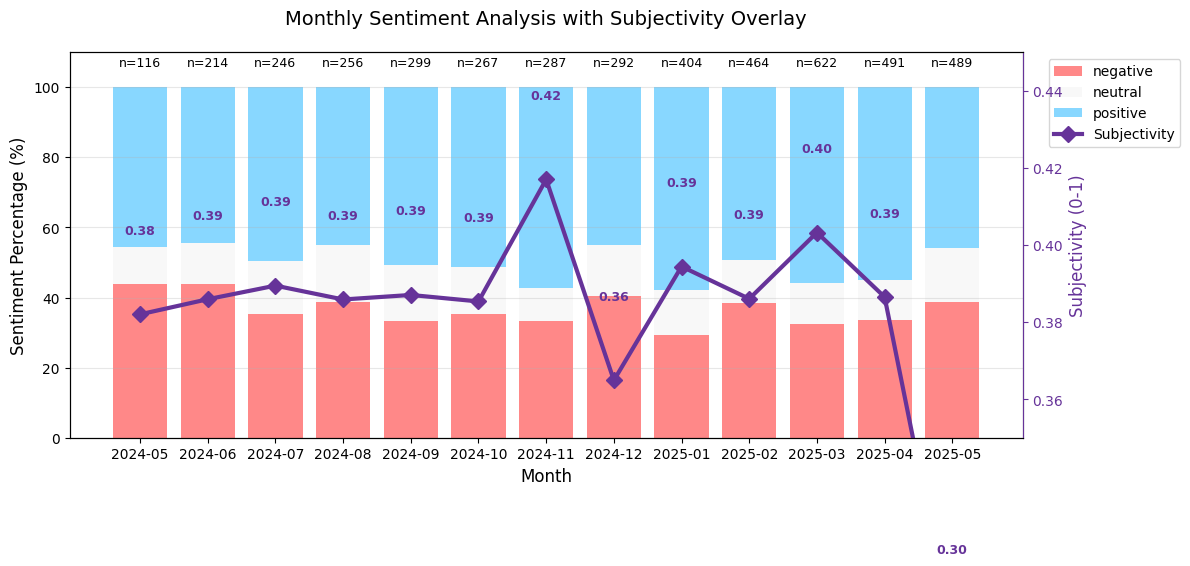

In [ ]:
subjectivity_avg = df_filtered.groupby('month')['subjectivity'].mean().reset_index()
for sentiment in ['negative', 'neutral', 'positive']:
    if sentiment in agg_df.columns:
        agg_df[f'{sentiment}_pct'] = (agg_df[sentiment] / agg_df['total']) * 100
    else:
        agg_df[f'{sentiment}_pct'] = 0
plt.figure(figsize=(14, 6))

ax1 = plt.gca()
colors = {'negative': '#ff6b6b', 'neutral': '#f7f7f7', 'positive': '#6bceff'}
bottom = None

for sentiment in ['negative', 'neutral', 'positive']:
    if sentiment in agg_df.columns:
        ax1.bar(agg_df['month'].astype(str), 
                agg_df[f'{sentiment}_pct'],
                bottom=bottom,
                color=colors[sentiment],
                alpha=0.8,  
                label=sentiment)
        bottom = agg_df[f'{sentiment}_pct'] if bottom is None else bottom + agg_df[f'{sentiment}_pct']

for i, row in agg_df.iterrows():
    bar_top = agg_df.loc[i, ['negative_pct', 'neutral_pct', 'positive_pct']].sum()
    ax1.text(i, bar_top + 3, f"n={row['total']}", ha='center', va='bottom', fontsize=9)


ax2 = ax1.twinx()
subjectivity_line = ax2.plot(
    subjectivity_avg['month'].astype(str),
    subjectivity_avg['subjectivity'],
    color='#663399',  
    marker='D',      
    markersize=8,
    linewidth=3,
    label='Subjectivity'
)

for x, y in zip(range(len(subjectivity_avg)), subjectivity_avg['subjectivity']):
    ax2.text(x, y+0.01, f'{y:.2f}',  
             ha='center', 
             va='bottom',
             color='#663399',
             fontsize=9,
             fontweight='bold')

# --- Customization ---
ax1.set_ylabel('Sentiment Percentage (%)', fontsize=12)
ax2.set_ylabel('Subjectivity (0-1)', fontsize=12, color='#663399')
ax1.set_xlabel('Month', fontsize=12)
ax1.set_title('Monthly Sentiment Analysis with Subjectivity Overlay', pad=20, fontsize=14)

# Set axis limits
ax1.set_ylim(0, 115)
ax2.set_ylim(0.35, 0.55)  # Extra space for labels

# Color the subjectivity axis
ax2.tick_params(axis='y', colors='#663399')
ax2.spines['right'].set_color('#663399')

# Combine legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='center left',
    bbox_to_anchor=(1.15, 0.5),  # <- increased from 1.02 to 1.15
    frameon=True
)

# Formatting
for label in ax1.get_xticklabels():
    label.set_rotation(45)
    label.set_fontsize(9)
    label.set_horizontalalignment('right')
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()